# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [44]:
import pandas as pd

df = pd.read_csv(
    "/content/athlete_events.csv",
)

df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [46]:
df.describe()

,ID,Age,Height,Weight,Year
count,271116.000000,261642.000000,210945.000000,208241.000000,271116.000000
mean,68248.954396,25.556898,175.338970,70.702393,1978.378480
std,39022.286345,6.393561,10.518462,14.348020,29.877632
min,1.000000,10.000000,127.000000,25.000000,1896.000000
25%,34643.000000,21.000000,168.000000,60.000000,1960.000000
50%,68205.000000,24.000000,175.000000,70.000000,1988.000000
75%,102097.250000,28.000000,183.000000,79.000000,2002.000000
max,135571.000000,97.000000,226.000000,214.000000,2016.000000


In [47]:
df.describe(include='object').T

,count,unique,top,freq
Name,271116,134732,Robert Tait McKenzie,58
Sex,271116,2,M,196594
Team,271116,1184,United States,17847
NOC,271116,230,USA,18853
Games,271116,51,2000 Summer,13821
Season,271116,2,Summer,222552
City,271116,42,London,22426
Sport,271116,66,Athletics,38624
Event,271116,765,Football Men's Football,5733
Medal,39783,3,Gold,13372


In [48]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  1385


In [49]:
df.isnull().sum().sort_values(ascending=False)

,0
Medal,231333
Weight,62875
Height,60171
Age,9474
Sex,0
ID,0
Name,0
Team,0
NOC,0
Year,0


Como podemos observar el dataset tiene un total de 15 variables con 271116 registros

Todas las variables tienen el tipo de dato correcto

Hay un total de 1385 duplicados

y contamos con variables que tienen grandes cantidades de datos nulos

Vamos a tratar los duplicados, los datos nulos y vamos a descartar las variables no utiles a continuacion

In [50]:
df.drop_duplicates(inplace=True)
print('Número de registros duplicados: ', df.duplicated().sum())
df.info()

Número de registros duplicados:  0
<class 'pandas.core.frame.DataFrame'>
Index: 269731 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      269731 non-null  int64  
 1   Name    269731 non-null  object 
 2   Sex     269731 non-null  object 
 3   Age     260416 non-null  float64
 4   Height  210917 non-null  float64
 5   Weight  208204 non-null  float64
 6   Team    269731 non-null  object 
 7   NOC     269731 non-null  object 
 8   Games   269731 non-null  object 
 9   Year    269731 non-null  int64  
 10  Season  269731 non-null  object 
 11  City    269731 non-null  object 
 12  Sport   269731 non-null  object 
 13  Event   269731 non-null  object 
 14  Medal   39772 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 32.9+ MB


In [51]:
df['Medal'].fillna('No medal', inplace=True)
df.dropna(inplace=True)
df.info()

/tmp/ipykernel_609/2147963353.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Medal'].fillna('No medal', inplace=True)


<class 'pandas.core.frame.DataFrame'>
Index: 206152 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      206152 non-null  int64  
 1   Name    206152 non-null  object 
 2   Sex     206152 non-null  object 
 3   Age     206152 non-null  float64
 4   Height  206152 non-null  float64
 5   Weight  206152 non-null  float64
 6   Team    206152 non-null  object 
 7   NOC     206152 non-null  object 
 8   Games   206152 non-null  object 
 9   Year    206152 non-null  int64  
 10  Season  206152 non-null  object 
 11  City    206152 non-null  object 
 12  Sport   206152 non-null  object 
 13  Event   206152 non-null  object 
 14  Medal   206152 non-null  object 
dtypes: float64(3), int64(2), object(10)
memory usage: 25.2+ MB


In [52]:
df.isnull().sum().sort_values(ascending=False)

,0
ID,0
Name,0
Sex,0
Age,0
Height,0
Weight,0
Team,0
NOC,0
Games,0
Year,0


In [53]:
df = df.drop(columns=['ID', 'Games', 'Name', 'Event', 'Team'])
df.head()

,Sex,Age,Height,Weight,NOC,Year,Season,City,Sport,Medal
0,M,24.0,180.0,80.0,CHN,1992,Summer,Barcelona,Basketball,No medal
1,M,23.0,170.0,60.0,CHN,2012,Summer,London,Judo,No medal
4,F,21.0,185.0,82.0,NED,1988,Winter,Calgary,Speed Skating,No medal
5,F,21.0,185.0,82.0,NED,1988,Winter,Calgary,Speed Skating,No medal
6,F,25.0,185.0,82.0,NED,1992,Winter,Albertville,Speed Skating,No medal


**Motivo de eliminacion**

**ID** Variable clave primaria

**Name** Variable con valor unico

**Game** Redundancia

**Event** Cardinalidad muy alta y muy especifica ademas con redundancia

**Team** Redundancia con NOC


Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [54]:
# variables categóricas y sus categorías

cat_vars = df.select_dtypes(include=["object"]).columns
for col in cat_vars:
    print(f'La columna "{col}" tiene las siguientes categorías: \n {df[col].unique()} \n')

La columna "Sex" tiene las siguientes categorías: 
 ['M' 'F'] 

La columna "NOC" tiene las siguientes categorías: 
 ['CHN' 'NED' 'USA' 'FIN' 'NOR' 'ROU' 'EST' 'FRA' 'ESP' 'EGY' 'BUL' 'ITA'
 'AZE' 'RUS' 'ARG' 'CUB' 'BLR' 'GRE' 'CMR' 'MEX' 'URS' 'NCA' 'HUN' 'NGR'
 'ALG' 'KUW' 'BRN' 'PAK' 'IRQ' 'LIB' 'QAT' 'MAS' 'IRI' 'CAN' 'IRL' 'AUS'
 'RSA' 'MAR' 'ERI' 'TAN' 'JOR' 'SUD' 'TUN' 'LBA' 'BEL' 'DJI' 'COM' 'KAZ'
 'BRU' 'KSA' 'MDV' 'ETH' 'INA' 'PHI' 'UZB' 'UAE' 'KGZ' 'TJK' 'EUN' 'JPN'
 'BRA' 'FRG' 'GDR' 'GER' 'ISR' 'SWE' 'ISV' 'TUR' 'SRI' 'ARM' 'CIV' 'KEN'
 'BEN' 'UKR' 'GHA' 'SOM' 'LAT' 'SYR' 'GBR' 'CHI' 'SUI' 'IND' 'POL' 'CRC'
 'PAN' 'GEO' 'SLO' 'CRO' 'GUY' 'POR' 'ANG' 'VEN' 'COL' 'BAN' 'PLE' 'PER'
 'URU' 'PUR' 'UGA' 'NZL' 'HON' 'ECU' 'TKM' 'MRI' 'TCH' 'SEY' 'MTN' 'CZE'
 'NIG' 'SKN' 'TTO' 'DOM' 'JAM' 'LBR' 'SUR' 'NEP' 'MGL' 'PLW' 'LTU' 'MON'
 'TOG' 'NAM' 'AHO' 'ISL' 'ASA' 'AUT' 'SAM' 'RWA' 'DMA' 'HAI' 'DEN' 'MLT'
 'LUX' 'CYP' 'GUI' 'ESA' 'BIZ' 'PAR' 'YMD' 'KOR' 'SGP' 'BER' 'SCG' 'SLE'
 'PNG' '

*   **Variables nominales:** Sex, NOC, Season, City, Sport
*   **Variable ordinal:** Medal
*   **Alta Cardinalidad:** NOC, City, Sport

**Procesamiento**

A las variables nominales (Sex, NOC, Season, City, Sport) se les debe dar un procesamiento con **OneHot Encoder** y a la variable ordinal (Medal) se le debe procesar con **Ordinal Encoder**.

Las variables descartadas son: **ID**, **Games**, **Name**, **Event**, **Team**.

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Weight'}>,
        <Axes: title={'center': 'Year'}>]], dtype=object)

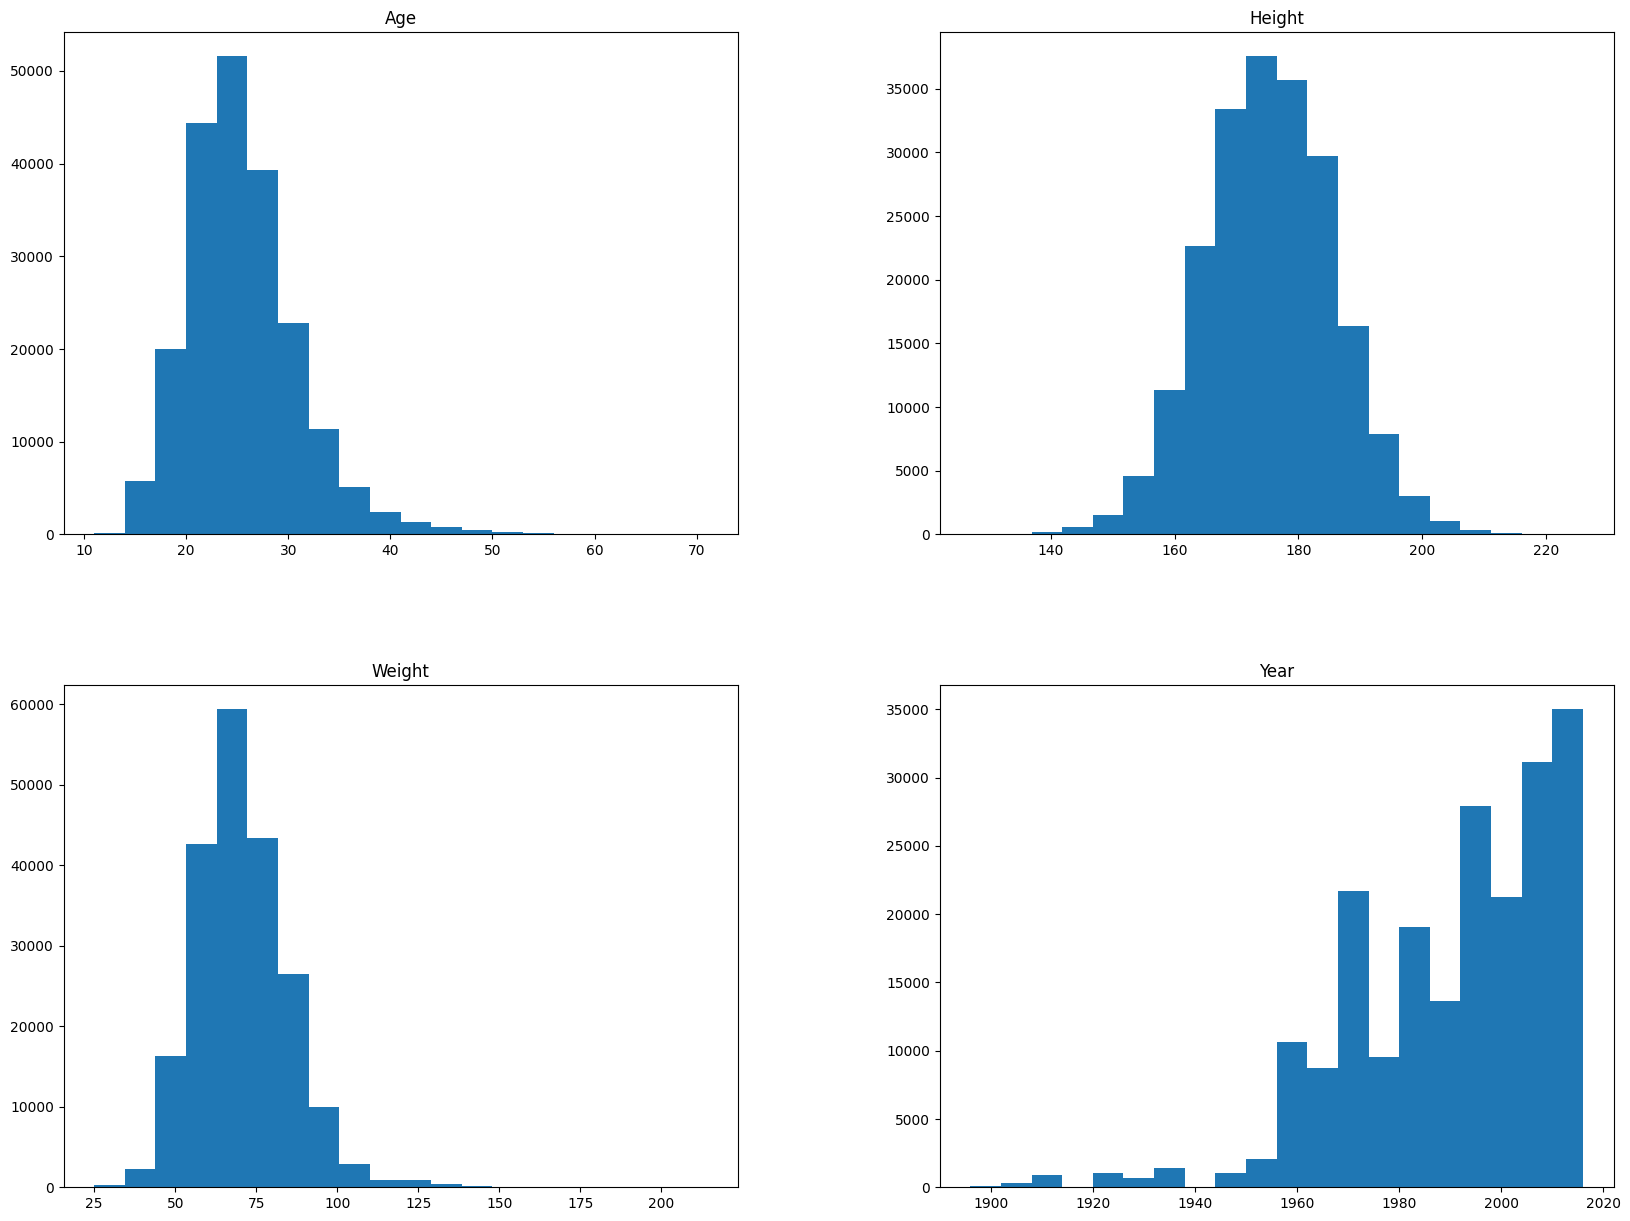

In [56]:
df.hist(
    figsize=(20, 15),
    bins=20,
    grid=False
    )

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>]], dtype=object)

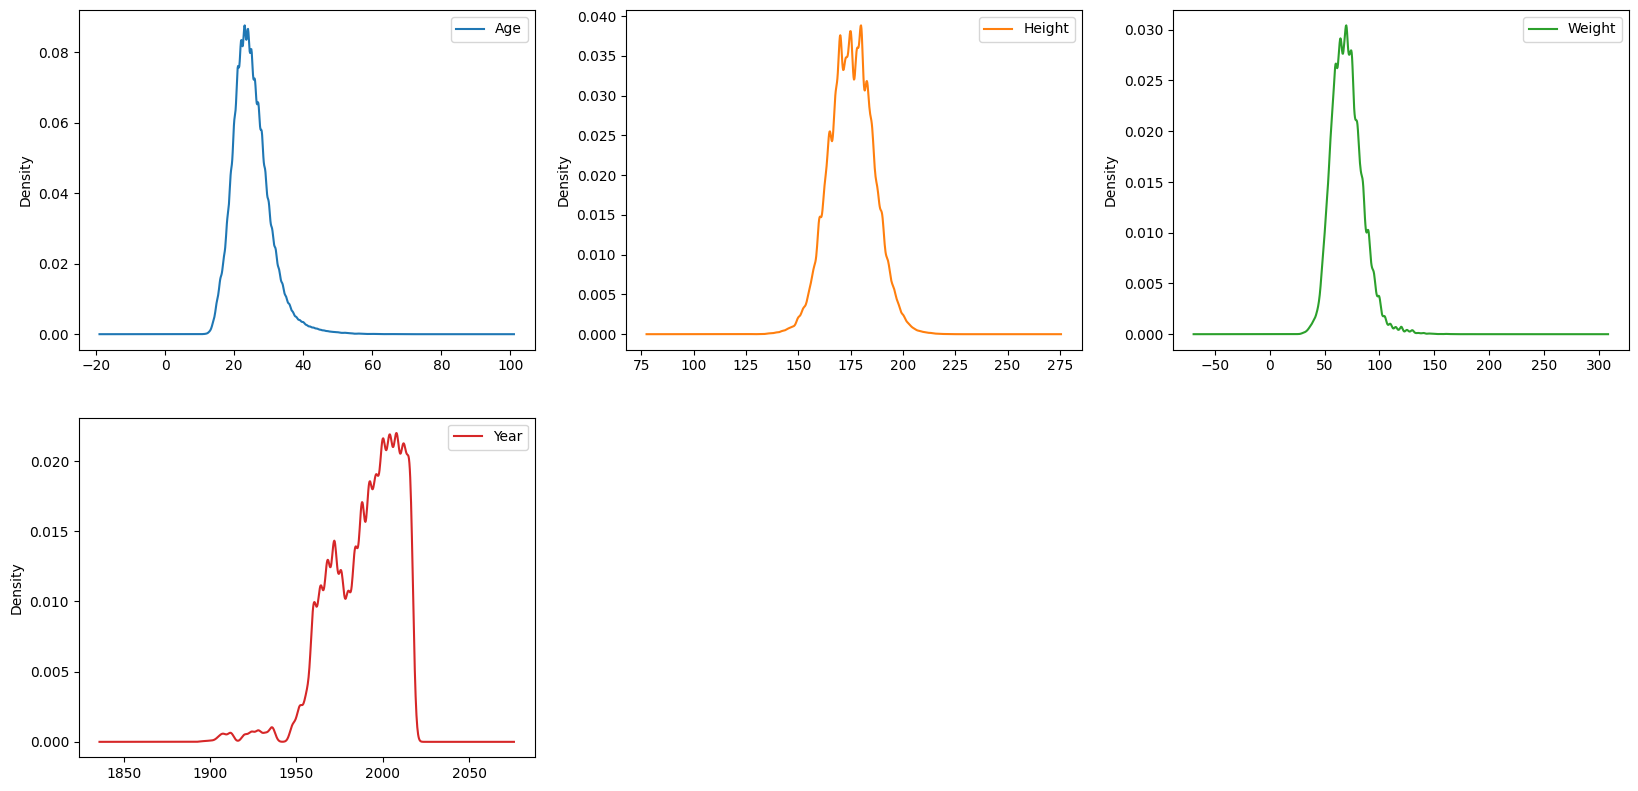

In [57]:
df.select_dtypes(include=['int64', 'float64']).plot(
    kind='kde',
    figsize=(20, 15),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
    )

,0
Age,"Axes(0.125,0.653529;0.227941x0.226471)"
Height,"Axes(0.398529,0.653529;0.227941x0.226471)"
Weight,"Axes(0.672059,0.653529;0.227941x0.226471)"
Year,"Axes(0.125,0.381765;0.227941x0.226471)"


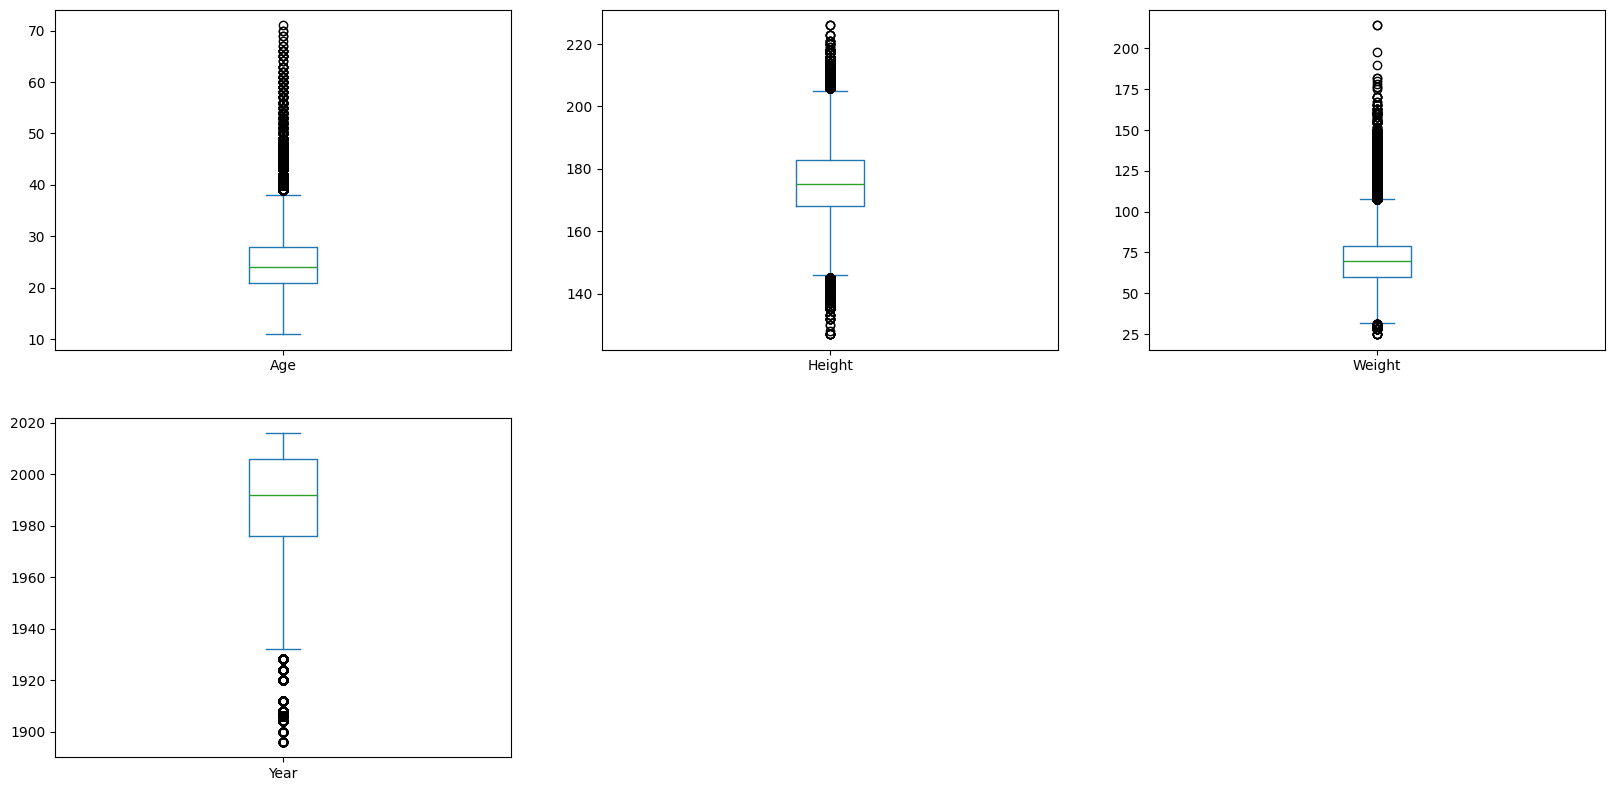

In [58]:
df.select_dtypes(include=['int64', 'float64']).plot(
    kind='box',
    figsize=(20, 15),
    subplots=True,
    layout=(3, 3),
    sharex=False,
    sharey=False
    )

**Variables que se aproximan a una normal:** Height

**Variables con valores atipicos:** Todas tienen valores atipicos

**Procesamiento**

En cuanto a las variables cuantitativas considero que en todos los casos se puede hacer un procesamiento, primero con **PowerTransformer** y luego con **StandarScaler** ya que una se aproxima mucho a una normal y las otras igual solo que con simetria diferente

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

<Axes: >

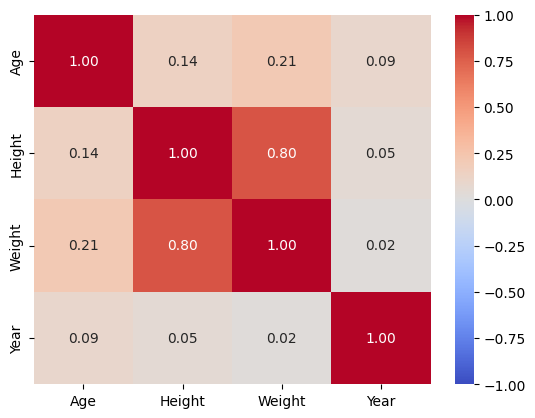

In [65]:
import seaborn as sns

corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

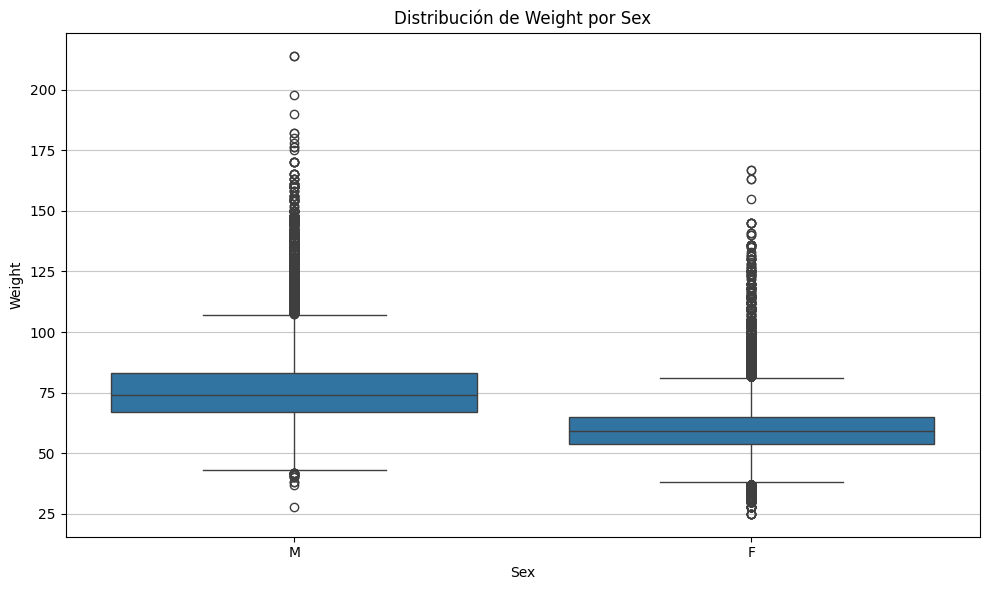

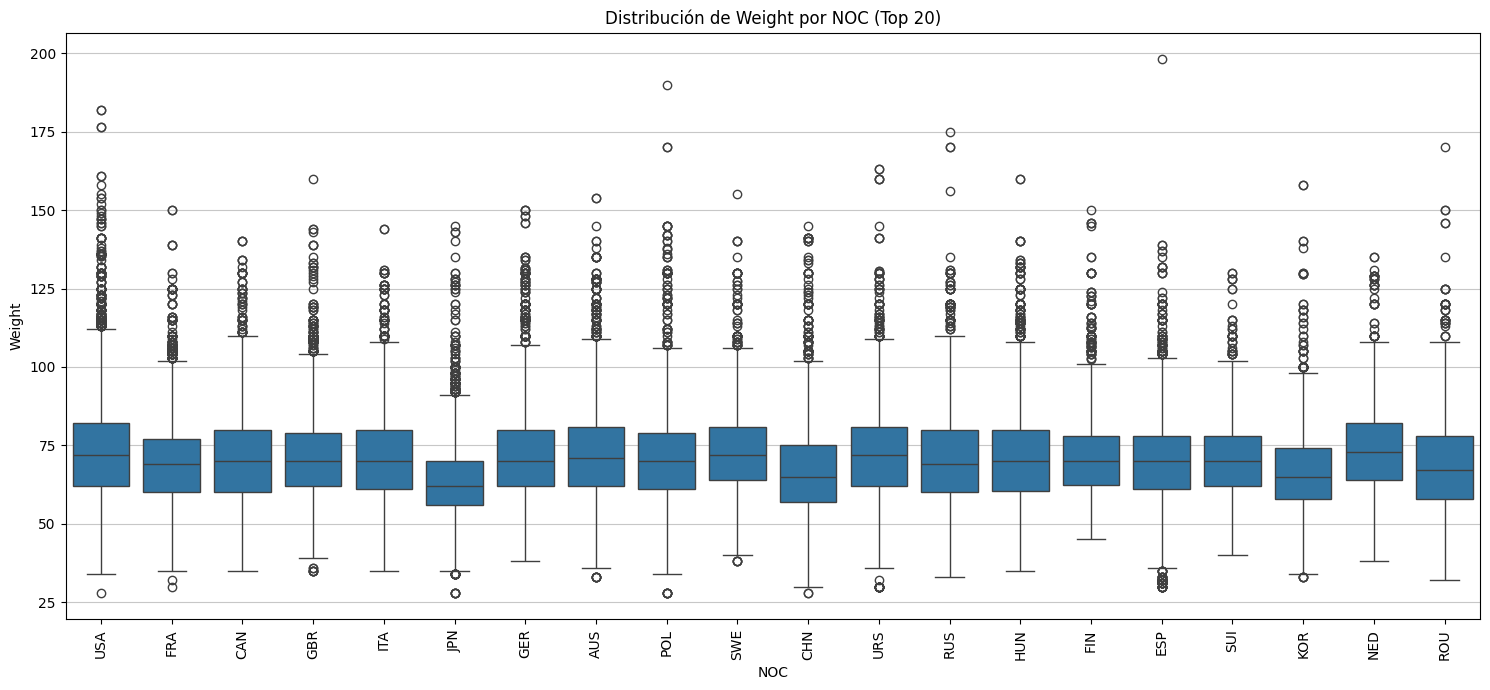

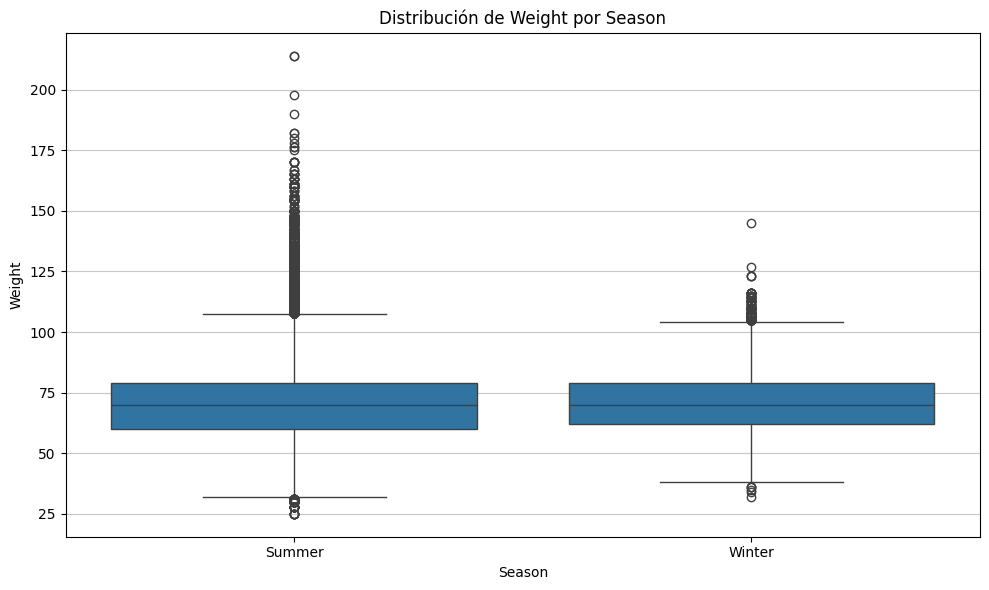

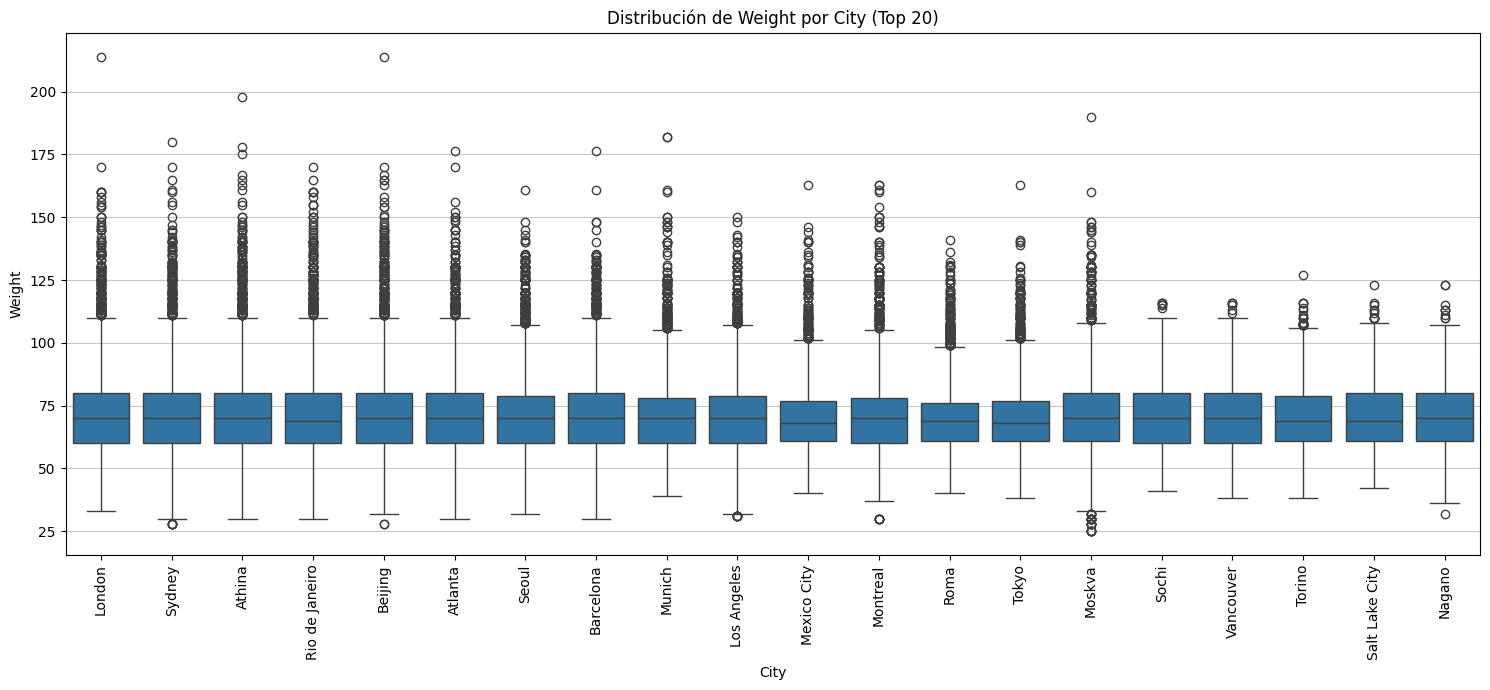

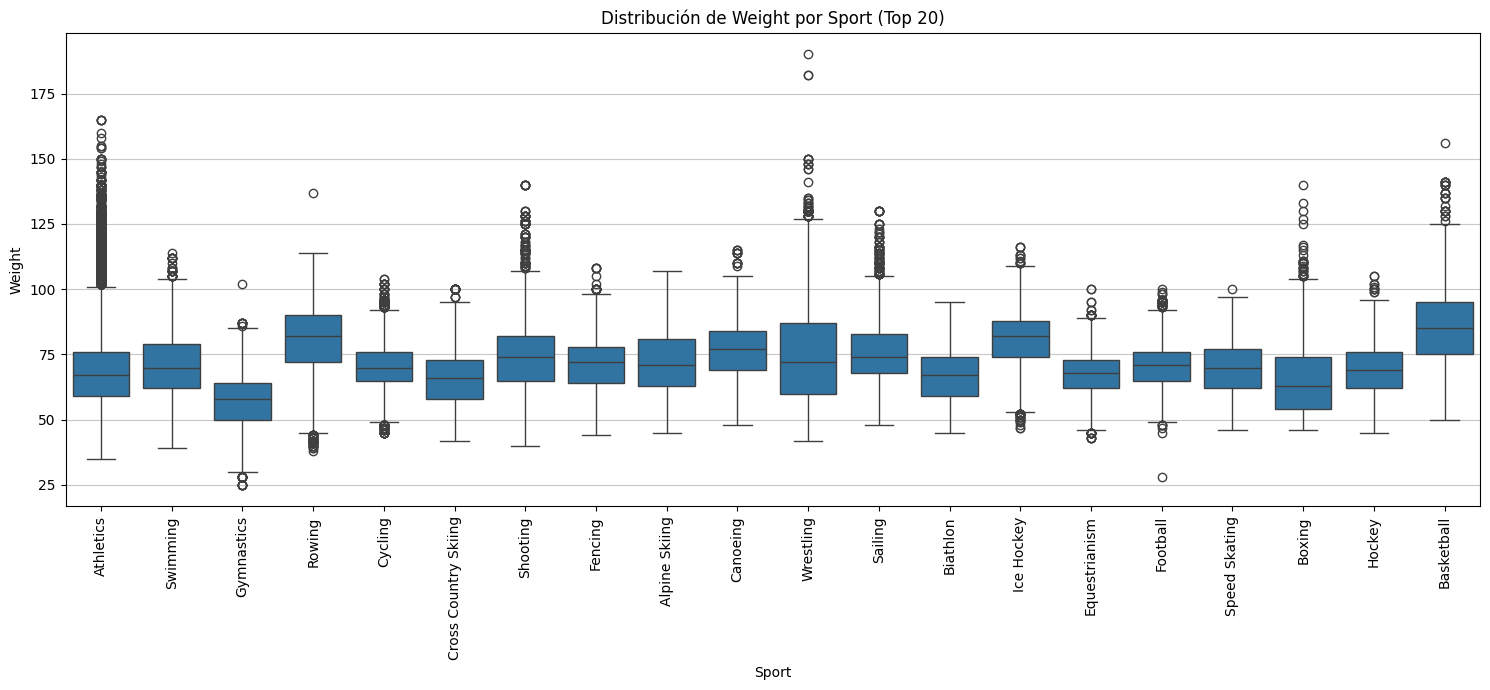

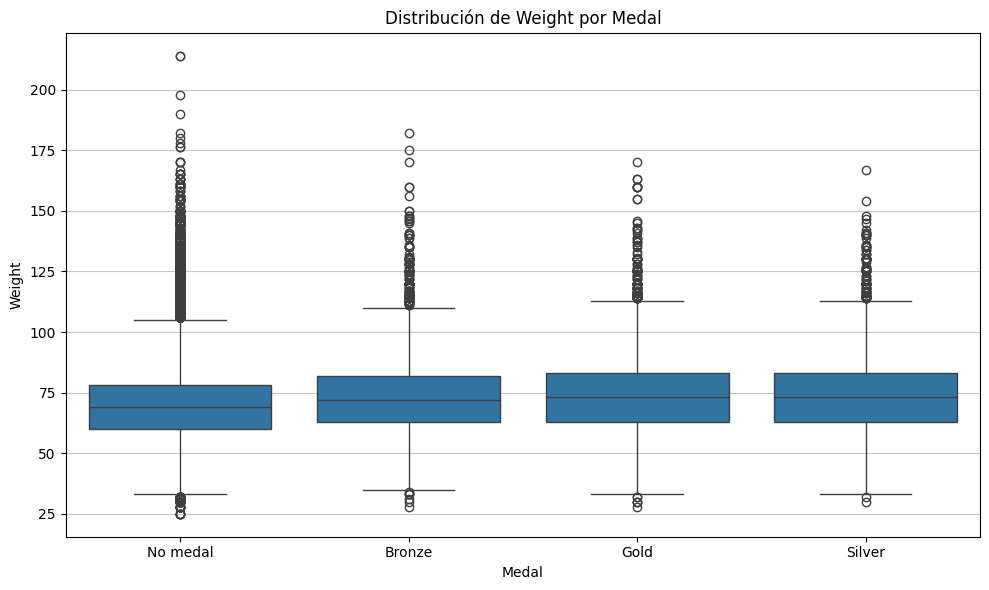

In [67]:
import matplotlib.pyplot as plt

for col in cat_vars:
    if df[col].nunique() > 20: # Si tiene más de 20 categorías, tomamos las 20 más frecuentes
        top_categories = df[col].value_counts().head(20).index.tolist()
        df_filtered = df[df[col].isin(top_categories)]
        plt.figure(figsize=(15, 7))
        sns.boxplot(x=col, y='Weight', data=df_filtered, order=top_categories)
        plt.title(f'Distribución de Weight por {col} (Top 20)')
        plt.xticks(rotation=90)
    else:
        plt.figure(figsize=(10, 6))
        sns.boxplot(x=col, y='Weight', data=df)
        plt.title(f'Distribución de Weight por {col}')

    plt.xlabel(col)
    plt.ylabel('Weight')
    plt.grid(axis='y', alpha=0.7)
    plt.tight_layout()
    plt.show()

*   **Variables Numéricas:**
    *   **Height** tiene una fuerte correlación positiva con **Weight** (alrededor de 0.8), lo que la convierte en un predictor muy fuerte.
    *   **Age** tiene una correlación positiva moderada con **Weight** (alrededor de 0.21).
    *   **Year** tiene una correlación muy débil con **Weight**, sugiriendo que el año de los juegos no es un buen predictor directo del peso.

*   **Variables Categóricas:**
    *   **Sex**: Los box plots muestran una clara diferencia en la distribución de **Weight** entre hombres y mujeres, siendo un predictor importante.
    *   **Sport**: Es un predictor muy influyente, ya que el peso varía significativamente entre disciplinas (ej. levantamiento de pesas vs. gimnasia).
    *   **Medal**: Podría haber diferencias sutiles en el peso promedio entre aquellos que ganaron medallas (Oro, Plata, Bronce) y los que no, pero esto dependerá mucho del deporte.
    *   **NOC** y **City**: Aunque tienen alta cardinalidad, podrían mostrar algunas variaciones en el peso.
    *   ***Season**: No hay una diferencia significativa en **Weight** entre atletas de Summer y Winter Games.

**Variables Potencialmente Buenas Predictoras de Weight:**

Basado en este análisis, las variables más prometedoras para predecir **Weight** son:

*   **Height** (Cuantitativa)
*   **Age** (Cuantitativa)
*   **Sex** (Nominal)
*   **Sport** (Nominal)
*   **Medal** (Ordinal)
*   **NOC** (Nominal, aunque con alta cardinalidad, puede ser relevante)
*   **City** (Nominal, aunque con alta cardinalidad, puede ser relevante)

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 206152 entries, 0 to 271115
Data columns (total 10 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Sex     206152 non-null  object 
 1   Age     206152 non-null  float64
 2   Height  206152 non-null  float64
 3   Weight  206152 non-null  float64
 4   NOC     206152 non-null  object 
 5   Year    206152 non-null  int64  
 6   Season  206152 non-null  object 
 7   City    206152 non-null  object 
 8   Sport   206152 non-null  object 
 9   Medal   206152 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 17.3+ MB


In [69]:
from sklearn.model_selection import train_test_split

X = df.drop(
    ['Weight'],
    axis=1
    )

y = df['Weight']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)

print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (164921, 9)
Tamaño del conjunto de prueba es: (41231, 9)


las variables elegidas para predecir **Weight** son:

*   **Height** (Cuantitativa)
*   **Age** (Cuantitativa)
*   **Sex** (Nominal)
*   **Sport** (Nominal)
*   **Medal** (Ordinal)

In [70]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, PowerTransformer

pt = PowerTransformer() # Para corregir la distribucion de las cuantitativas 1.
ss = StandardScaler() # Para corregir la escala de las cuantitativas 2.
orden = ['No medal', 'Bronze', 'Silver', 'Gold']
ore = OrdinalEncoder(categories=[orden], dtype='int') # Para preprocesar Medal
ohe = OneHotEncoder(sparse_output=False, drop='if_binary') # Sex, Sport

In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

Cualitativas_Pipeline = Pipeline([
    ('pt', pt),
    ('ss', ss)
])

preprocessor = ColumnTransformer(transformers=[
    ('Height_Age', Cualitativas_Pipeline, ['Height', 'Age']),
    ('Medal', ore, ['Medal']),
    ('Sex_Sport', ohe, ['Sex', 'Sport'])
    ],
    remainder='drop') # El resto de las características se descartan

preprocessor

ColumnTransformer(transformers=[('Height_Age',
                                 Pipeline(steps=[('pt', PowerTransformer()),
                                                 ('ss', StandardScaler())]),
                                 ['Height', 'Age']),
                                ('Medal',
                                 OrdinalEncoder(categories=[['No medal',
                                                             'Bronze', 'Silver',
                                                             'Gold']],
                                                dtype='int'),
                                 ['Medal']),
                                ('Sex_Sport',
                                 OneHotEncoder(drop='if_binary',
                                               sparse_output=False),
                                 ['Sex', 'Sport'])])

In [76]:
from sklearn.linear_model import Ridge

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
    ])

pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Height_Age',
                                                  Pipeline(steps=[('pt',
                                                                   PowerTransformer()),
                                                                  ('ss',
                                                                   StandardScaler())]),
                                                  ['Height', 'Age']),
                                                 ('Medal',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'medal',
                                                                              'Bronze',
                                                                              'Silver',
                                                                              'Gold']],
                                                                 dtype='int'),
                                                  ['Medal']),
                                                 ('Sex_Sport',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['Sex', 'Sport'])])),
                ('model', Ridge())])

In [78]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('Height_Age',
                                                  Pipeline(steps=[('pt',
                                                                   PowerTransformer()),
                                                                  ('ss',
                                                                   StandardScaler())]),
                                                  ['Height', 'Age']),
                                                 ('Medal',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'medal',
                                                                              'Bronze',
                                                                              'Silver',
                                                                              'Gold']],
                                                                 dtype='int'),
                                                  ['Medal']),
                                                 ('Sex_Sport',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['Sex', 'Sport'])])),
                ('model', Ridge())])

In [79]:
print(f'Exactitud del modelo en el conjunto de entrenamiento: {pipeline.score(X_train, y_train)}')
print(f'Exactitud del modelo en el conjunto de prueba: {pipeline.score(X_test, y_test)}')

Exactitud del modelo en el conjunto de entrenamiento: 0.7295539325855813
Exactitud del modelo en el conjunto de prueba: 0.7322811505071894


In [80]:
transformed_features = preprocessor.get_feature_names_out()

print("Características con las que se entrenó el modelo:")
for feature in transformed_features:
    print(f"- {feature}")

Características con las que se entrenó el modelo:
- Height_Age__Height
- Height_Age__Age
- Medal__Medal
- Sex_Sport__Sex_M
- Sex_Sport__Sport_Alpine Skiing
- Sex_Sport__Sport_Archery
- Sex_Sport__Sport_Art Competitions
- Sex_Sport__Sport_Athletics
- Sex_Sport__Sport_Badminton
- Sex_Sport__Sport_Baseball
- Sex_Sport__Sport_Basketball
- Sex_Sport__Sport_Beach Volleyball
- Sex_Sport__Sport_Biathlon
- Sex_Sport__Sport_Bobsleigh
- Sex_Sport__Sport_Boxing
- Sex_Sport__Sport_Canoeing
- Sex_Sport__Sport_Cross Country Skiing
- Sex_Sport__Sport_Curling
- Sex_Sport__Sport_Cycling
- Sex_Sport__Sport_Diving
- Sex_Sport__Sport_Equestrianism
- Sex_Sport__Sport_Fencing
- Sex_Sport__Sport_Figure Skating
- Sex_Sport__Sport_Football
- Sex_Sport__Sport_Freestyle Skiing
- Sex_Sport__Sport_Golf
- Sex_Sport__Sport_Gymnastics
- Sex_Sport__Sport_Handball
- Sex_Sport__Sport_Hockey
- Sex_Sport__Sport_Ice Hockey
- Sex_Sport__Sport_Judo
- Sex_Sport__Sport_Lacrosse
- Sex_Sport__Sport_Luge
- Sex_Sport__Sport_Modern 

Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [86]:
re_preprocessor = ColumnTransformer(transformers=[
    ('Height_Age', Cualitativas_Pipeline, ['Height', 'Age']),
    ('Medal', ore, ['Medal']),
    ('Sex_Sport', ohe, ['Sex', 'Sport', 'NOC', 'City']),
    ],
    remainder='drop') # El resto de las características se descartan

re_preprocessor

ColumnTransformer(transformers=[('Height_Age',
                                 Pipeline(steps=[('pt', PowerTransformer()),
                                                 ('ss', StandardScaler())]),
                                 ['Height', 'Age']),
                                ('Medal',
                                 OrdinalEncoder(categories=[['No medal',
                                                             'Bronze', 'Silver',
                                                             'Gold']],
                                                dtype='int'),
                                 ['Medal']),
                                ('Sex_Sport',
                                 OneHotEncoder(drop='if_binary',
                                               sparse_output=False),
                                 ['Sex', 'Sport', 'NOC', 'City'])])

In [87]:
re_pipeline = Pipeline(steps=[
    ('re_preprocessor', re_preprocessor),
    ('model', Ridge())
    ])

re_pipeline

Pipeline(steps=[('re_preprocessor',
                 ColumnTransformer(transformers=[('Height_Age',
                                                  Pipeline(steps=[('pt',
                                                                   PowerTransformer()),
                                                                  ('ss',
                                                                   StandardScaler())]),
                                                  ['Height', 'Age']),
                                                 ('Medal',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'medal',
                                                                              'Bronze',
                                                                              'Silver',
                                                                              'Gold']],
                                                                 dtype='int'),
                                                  ['Medal']),
                                                 ('Sex_Sport',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['Sex', 'Sport', 'NOC',
                                                   'City'])])),
                ('model', Ridge())])

In [88]:
re_pipeline.fit(X_train, y_train)

Pipeline(steps=[('re_preprocessor',
                 ColumnTransformer(transformers=[('Height_Age',
                                                  Pipeline(steps=[('pt',
                                                                   PowerTransformer()),
                                                                  ('ss',
                                                                   StandardScaler())]),
                                                  ['Height', 'Age']),
                                                 ('Medal',
                                                  OrdinalEncoder(categories=[['No '
                                                                              'medal',
                                                                              'Bronze',
                                                                              'Silver',
                                                                              'Gold']],
                                                                 dtype='int'),
                                                  ['Medal']),
                                                 ('Sex_Sport',
                                                  OneHotEncoder(drop='if_binary',
                                                                sparse_output=False),
                                                  ['Sex', 'Sport', 'NOC',
                                                   'City'])])),
                ('model', Ridge())])

In [89]:
print(f'Exactitud del modelo en el conjunto de entrenamiento: {re_pipeline.score(X_train, y_train)}')
print(f'Exactitud del modelo en el conjunto de prueba: {pipeline.score(X_test, y_test)}')

Exactitud del modelo en el conjunto de entrenamiento: 0.7356101048687237
Exactitud del modelo en el conjunto de prueba: 0.737016038151977


In [91]:
re_transformed_features = re_preprocessor.get_feature_names_out()

print("Características con las que se entrenó el modelo:")
for feature in re_transformed_features:
    print(f"- {feature}")

Características con las que se entrenó el modelo:
- Height_Age__Height
- Height_Age__Age
- Medal__Medal
- Sex_Sport__Sex_M
- Sex_Sport__Sport_Alpine Skiing
- Sex_Sport__Sport_Archery
- Sex_Sport__Sport_Art Competitions
- Sex_Sport__Sport_Athletics
- Sex_Sport__Sport_Badminton
- Sex_Sport__Sport_Baseball
- Sex_Sport__Sport_Basketball
- Sex_Sport__Sport_Beach Volleyball
- Sex_Sport__Sport_Biathlon
- Sex_Sport__Sport_Bobsleigh
- Sex_Sport__Sport_Boxing
- Sex_Sport__Sport_Canoeing
- Sex_Sport__Sport_Cross Country Skiing
- Sex_Sport__Sport_Curling
- Sex_Sport__Sport_Cycling
- Sex_Sport__Sport_Diving
- Sex_Sport__Sport_Equestrianism
- Sex_Sport__Sport_Fencing
- Sex_Sport__Sport_Figure Skating
- Sex_Sport__Sport_Football
- Sex_Sport__Sport_Freestyle Skiing
- Sex_Sport__Sport_Golf
- Sex_Sport__Sport_Gymnastics
- Sex_Sport__Sport_Handball
- Sex_Sport__Sport_Hockey
- Sex_Sport__Sport_Ice Hockey
- Sex_Sport__Sport_Judo
- Sex_Sport__Sport_Lacrosse
- Sex_Sport__Sport_Luge
- Sex_Sport__Sport_Modern 